# Exploring real-time fraud detection with Elliptic

I use this notebook to understand the Elliptic transaction graph and test the main ideas before moving them into the project modules. The experiment follows the same temporal split and feature restrictions as the production pipeline.

## 1. Setup

The project dependencies should already be installed from `requirements.txt`. I set a seed so the sampling and model initialization are repeatable.

In [1]:
from pathlib import Path
import heapq
import random
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import average_precision_score, confusion_matrix, f1_score, precision_score, recall_score
from threadpoolctl import threadpool_limits
from torch import nn
from torch.nn import functional
from torch_geometric.datasets import EllipticBitcoinDataset
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import SAGEConv
from xgboost import XGBClassifier

In [2]:
project_root = Path.cwd()
if not (project_root / "src").exists():
    project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
data_root = project_root / "data" / "raw" / "elliptic"
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## 2. Load and inspect the graph

Elliptic contains Bitcoin transactions as nodes and payment flows as directed edges. The first 93 columns describe the transaction itself. I leave out the 72 aggregated neighbour features because they would not necessarily be available when a new transaction arrives.

In [3]:
dataset = EllipticBitcoinDataset(root=str(data_root))
data = dataset[0].clone()
raw_features = pd.read_csv(dataset.raw_paths[0], header=None)
local_feature_count = 93
data.x = data.x[:, :local_feature_count]
data.time_step = torch.tensor(raw_features[1].to_numpy(), dtype=torch.long)

In [4]:
print("Nodes:", data.num_nodes)
print("Edges:", data.num_edges)
print("Local features:", data.num_node_features)
print("Timesteps:", int(data.time_step.min()), "to", int(data.time_step.max()))
print("Labels:", torch.unique(data.y).tolist())

Nodes: 203769
Edges: 234355
Local features: 93
Timesteps: 1 to 49
Labels: [0, 1, 2]


### Class distribution

Labels 0 and 1 mean licit and illicit. Label 2 is unknown, so it must not be used as a supervised target.

,transactions
licit,42019
illicit,4545
unknown,157205


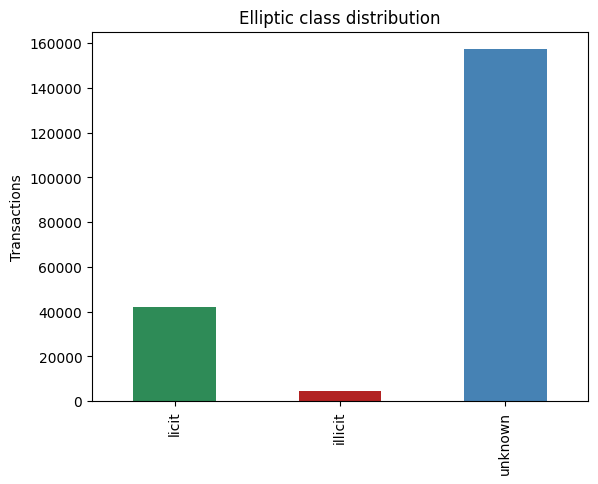

In [5]:
labels, counts = torch.unique(data.y, return_counts=True)
class_names = {0: "licit", 1: "illicit", 2: "unknown"}
class_counts = pd.Series(counts.tolist(), index=[class_names[label] for label in labels.tolist()])
display(class_counts.to_frame("transactions"))
class_counts.plot.bar(color=["seagreen", "firebrick", "steelblue"], title="Elliptic class distribution")
plt.ylabel("Transactions")
plt.show()

## 3. Temporal train, validation and test split

A random split would let the model learn from future transactions. I train on timesteps 1–30, choose settings and thresholds on 31–34, and reserve 35–49 for the final test.

In [6]:
train_period = (1, 30)
validation_period = (31, 34)
test_period = (35, 49)

def period_mask(time_step, period):
    start, end = period
    return (time_step >= start) & (time_step <= end)

In [7]:
known = data.y != 2
data.train_mask = period_mask(data.time_step, train_period) & known
data.val_mask = period_mask(data.time_step, validation_period) & known
data.test_mask = period_mask(data.time_step, test_period) & known

In [8]:
split_counts = pd.Series({"train": int(data.train_mask.sum()), "validation": int(data.val_mask.sum()), "test": int(data.test_mask.sum())})
display(split_counts.to_frame("known labels"))
assert not torch.any(data.train_mask & data.val_mask)
assert not torch.any(data.val_mask & data.test_mask)

,known labels
train,26905
validation,2989
test,16670


### Temporal graph snapshots

The node masks are not enough for a GNN. Each split also needs a graph snapshot that excludes nodes and edges from later timesteps.

In [9]:
def build_snapshot(data, history_end, target_period):
    node_ids = (data.time_step <= history_end).nonzero(as_tuple=False).view(-1)
    snapshot = data.subgraph(node_ids)
    snapshot.node_id = node_ids
    snapshot.target_mask = period_mask(snapshot.time_step, target_period) & (snapshot.y != 2)
    return snapshot

In [10]:
train_snapshot = build_snapshot(data, train_period[1], train_period)
validation_snapshot = build_snapshot(data, validation_period[1], validation_period)
test_snapshot = build_snapshot(data, test_period[1], test_period)
print("Train snapshot:", train_snapshot.num_nodes, "nodes and", train_snapshot.num_edges, "edges")
print("Validation snapshot:", validation_snapshot.num_nodes, "nodes and", validation_snapshot.num_edges, "edges")
assert int(train_snapshot.time_step.max()) <= train_period[1]
assert int(validation_snapshot.time_step.max()) <= validation_period[1]

Train snapshot: 123287 nodes and 142784 edges
Validation snapshot: 136265 nodes and 156843 edges


## 4. XGBoost baseline

Before using graph information, I need a tabular baseline using only the 93 local transaction features.

In [11]:
def train_baseline(data):
    x_train = data.x[data.train_mask].numpy()
    y_train = data.y[data.train_mask].numpy()
    model = XGBClassifier(objective="binary:logistic", eval_metric="logloss", random_state=42, n_jobs=1)
    with threadpool_limits(limits=1):
        model.fit(x_train, y_train)
    return model

In [12]:
threshold_grid = (0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 0.85)

def classification_metrics(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    return {"average_precision": average_precision_score(labels, probabilities), "precision": precision_score(labels, predictions, zero_division=0), "recall": recall_score(labels, predictions, zero_division=0), "f1": f1_score(labels, predictions, zero_division=0), "confusion_matrix": confusion_matrix(labels, predictions, labels=[0, 1])}

def select_threshold(labels, probabilities):
    scores = {threshold: classification_metrics(labels, probabilities, threshold) for threshold in threshold_grid}
    return max(scores, key=lambda threshold: scores[threshold]["f1"])

In [13]:
baseline_model = train_baseline(data)
validation_labels = data.y[data.val_mask].numpy()
validation_probabilities = baseline_model.predict_proba(data.x[data.val_mask].numpy())[:, 1]
baseline_threshold = select_threshold(validation_labels, validation_probabilities)
print("Selected baseline threshold:", baseline_threshold)

Selected baseline threshold: 0.5


In [14]:
threshold_rows = []
for threshold in threshold_grid:
    metrics = classification_metrics(validation_labels, validation_probabilities, threshold)
    threshold_rows.append({"threshold": threshold, "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"]})
display(pd.DataFrame(threshold_rows).round(4))

,threshold,precision,recall,f1
0,0.10,0.8765,0.9783,0.9247
1,0.20,0.9250,0.9705,0.9472
2,0.30,0.9349,0.9606,0.9476
3,0.40,0.9489,0.9508,0.9499
4,0.50,0.9581,0.9449,0.9514
5,0.70,0.9771,0.9252,0.9505
6,0.85,0.9889,0.8760,0.9290


In [15]:
test_labels = data.y[data.test_mask].numpy()
test_probabilities = baseline_model.predict_proba(data.x[data.test_mask].numpy())[:, 1]
baseline_validation = classification_metrics(validation_labels, validation_probabilities, baseline_threshold)
baseline_test = classification_metrics(test_labels, test_probabilities, baseline_threshold)
print("Validation average precision:", round(baseline_validation["average_precision"], 4))
print("Test average precision:", round(baseline_test["average_precision"], 4))
print("Test confusion matrix:")
print(baseline_test["confusion_matrix"])

Validation average precision: 0.9898
Test average precision: 0.7695
Test confusion matrix:
[[15362   225]
 [  329   754]]


## 5. GraphSAGE encoder

The baseline ignores payment relationships. I use two mean aggregation GraphSAGE layers to learn a 64-dimensional representation for each transaction.

In [16]:
class GraphSAGEEncoder(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, embedding_dim=64, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.conv1 = SAGEConv(in_channels, hidden_channels, aggr="mean")
        self.conv2 = SAGEConv(hidden_channels, embedding_dim, aggr="mean")

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = functional.relu(x)
        x = functional.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return functional.normalize(x, p=2, dim=-1)

In [17]:
class GraphSAGEClassifier(nn.Module):
    def __init__(self, in_channels, hidden_channels=128, embedding_dim=64, dropout=0.5):
        super().__init__()
        self.encoder = GraphSAGEEncoder(in_channels, hidden_channels, embedding_dim, dropout)
        self.classifier = nn.Linear(embedding_dim, 2)

    def forward(self, x, edge_index):
        embeddings = self.encoder(x, edge_index)
        return self.classifier(embeddings), embeddings

In [18]:
def create_neighbor_loader(snapshot, shuffle=False):
    return NeighborLoader(snapshot, input_nodes=snapshot.target_mask, num_neighbors=[25, 10], batch_size=512, shuffle=shuffle, time_attr="time_step")

train_loader = create_neighbor_loader(train_snapshot, shuffle=True)
validation_loader = create_neighbor_loader(validation_snapshot)
sample_batch = next(iter(train_loader))
print("Seed nodes:", sample_batch.batch_size)
print("Sampled nodes:", sample_batch.num_nodes)

Seed nodes: 512
Sampled nodes: 2042


In [19]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    total_nodes = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits, _ = model(batch.x, batch.edge_index)
        loss = functional.cross_entropy(logits[:batch.batch_size], batch.y[:batch.batch_size])
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.batch_size
        total_nodes += batch.batch_size
    return total_loss / total_nodes

In [20]:
@torch.no_grad()
def evaluate_graphsage(model, loader):
    model.eval()
    probabilities = []
    labels = []
    for batch in loader:
        batch = batch.to(device)
        logits, _ = model(batch.x, batch.edge_index)
        probabilities.append(torch.softmax(logits[:batch.batch_size], dim=1)[:, 1].cpu())
        labels.append(batch.y[:batch.batch_size].cpu())
    return average_precision_score(torch.cat(labels).numpy(), torch.cat(probabilities).numpy())

In [21]:
gnn_model = GraphSAGEClassifier(data.num_node_features).to(device)
optimizer = torch.optim.Adam(gnn_model.parameters(), lr=0.001, weight_decay=5e-4)
best_score = float("-inf")
best_state = None

In [22]:
exploration_epochs = 3
for epoch in range(1, exploration_epochs + 1):
    train_loss = train_one_epoch(gnn_model, train_loader, optimizer)
    validation_score = evaluate_graphsage(gnn_model, validation_loader)
    print(f"Epoch {epoch:02d} | Loss: {train_loss:.4f} | Validation average precision: {validation_score:.4f}")
    if validation_score > best_score:
        best_score = validation_score
        best_state = {name: value.detach().cpu().clone() for name, value in gnn_model.state_dict().items()}
gnn_model.load_state_dict(best_state)
gnn_model.to(device)

Epoch 01 | Loss: 0.3963 | Validation average precision: 0.6108


Epoch 02 | Loss: 0.2420 | Validation average precision: 0.7824


Epoch 03 | Loss: 0.1682 | Validation average precision: 0.9027


GraphSAGEClassifier(
  (encoder): GraphSAGEEncoder(
    (conv1): SAGEConv(93, 128, aggr=mean)
    (conv2): SAGEConv(128, 64, aggr=mean)
  )
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

## 6. Hybrid GraphSAGE and XGBoost model

GraphSAGE provides graph context, while XGBoost handles the final decision boundary. I concatenate 93 local features with the 64-dimensional embedding, giving 157 features.

In [23]:
@torch.no_grad()
def extract_embeddings(encoder, snapshot):
    encoder.eval()
    raw_batches = []
    embedding_batches = []
    label_batches = []
    for batch in create_neighbor_loader(snapshot):
        batch = batch.to(device)
        embeddings = encoder(batch.x, batch.edge_index)
        seed_count = batch.batch_size
        raw_batches.append(batch.x[:seed_count].cpu())
        embedding_batches.append(embeddings[:seed_count].cpu())
        label_batches.append(batch.y[:seed_count].cpu())
    raw = torch.cat(raw_batches).numpy()
    embeddings = torch.cat(embedding_batches).numpy()
    labels = torch.cat(label_batches).numpy()
    return raw, embeddings, labels

In [24]:
train_raw, train_embeddings, train_labels = extract_embeddings(gnn_model.encoder, train_snapshot)
validation_raw, validation_embeddings, validation_labels = extract_embeddings(gnn_model.encoder, validation_snapshot)
test_raw, test_embeddings, test_labels = extract_embeddings(gnn_model.encoder, test_snapshot)
print("Raw feature shape:", train_raw.shape)
print("Embedding shape:", train_embeddings.shape)

Raw feature shape: (26905, 93)
Embedding shape: (26905, 64)


In [25]:
train_hybrid = np.concatenate((train_raw, train_embeddings), axis=1)
validation_hybrid = np.concatenate((validation_raw, validation_embeddings), axis=1)
test_hybrid = np.concatenate((test_raw, test_embeddings), axis=1)
hybrid_model = XGBClassifier(objective="binary:logistic", eval_metric="logloss", max_depth=6, random_state=42, n_jobs=1)
with threadpool_limits(limits=1):
    hybrid_model.fit(train_hybrid, train_labels)
print("Hybrid features:", train_hybrid.shape[1])

Hybrid features: 157


In [26]:
hybrid_validation_probabilities = hybrid_model.predict_proba(validation_hybrid)[:, 1]
hybrid_threshold = select_threshold(validation_labels, hybrid_validation_probabilities)
hybrid_test_probabilities = hybrid_model.predict_proba(test_hybrid)[:, 1]
hybrid_validation = classification_metrics(validation_labels, hybrid_validation_probabilities, hybrid_threshold)
hybrid_test = classification_metrics(test_labels, hybrid_test_probabilities, hybrid_threshold)
print("Selected hybrid threshold:", hybrid_threshold)

Selected hybrid threshold: 0.4


In [27]:
comparison = pd.DataFrame({"baseline validation": baseline_validation, "hybrid validation": hybrid_validation, "baseline test": baseline_test, "hybrid test": hybrid_test}).drop(index="confusion_matrix").T
display(comparison.round(4))
print("Hybrid test confusion matrix:")
print(hybrid_test["confusion_matrix"])

,average_precision,precision,recall,f1
baseline validation,0.989777,0.958084,0.944882,0.951437
hybrid validation,0.985798,0.950397,0.942913,0.94664
baseline test,0.769457,0.770174,0.696214,0.731329
hybrid test,0.76891,0.732126,0.709141,0.72045


Hybrid test confusion matrix:
[[15306   281]
 [  315   768]]


## 7. Explore the streaming representation

For online inference, a Kafka event carries one node's local features and its incoming transaction IDs. Parents must be published before their children so the consumer can build graph state from events it has already seen.

In [28]:
def build_stream_graph(data, node_ids):
    selected = set(node_ids)
    incoming = {node_id: [] for node_id in node_ids}
    outgoing = {node_id: [] for node_id in node_ids}
    source_nodes, target_nodes = data.edge_index.tolist()
    for source, target in zip(source_nodes, target_nodes):
        if source in selected and target in selected:
            incoming[target].append(source)
            outgoing[source].append(target)
    return incoming, outgoing

In [29]:
def order_stream(data, node_ids, incoming, outgoing):
    indegree = {node_id: len(incoming[node_id]) for node_id in node_ids}
    queue = [(int(data.time_step[node_id]), node_id) for node_id in node_ids if indegree[node_id] == 0]
    heapq.heapify(queue)
    ordered = []
    while queue:
        _, node_id = heapq.heappop(queue)
        ordered.append(node_id)
        for target in outgoing[node_id]:
            indegree[target] -= 1
            if indegree[target] == 0:
                heapq.heappush(queue, (int(data.time_step[target]), target))
    return ordered

In [30]:
test_node_ids = period_mask(data.time_step, test_period).nonzero(as_tuple=False).view(-1).tolist()
incoming_neighbors, outgoing_neighbors = build_stream_graph(data, test_node_ids)
ordered_node_ids = order_stream(data, test_node_ids, incoming_neighbors, outgoing_neighbors)
assert len(ordered_node_ids) == len(test_node_ids)
print("Prepared events:", len(ordered_node_ids))

Prepared events: 67504


In [31]:
def build_event(data, node_id, incoming_neighbors):
    return {"schema_version": 2, "node_id": node_id, "time_step": int(data.time_step[node_id]), "features": data.x[node_id].tolist(), "incoming_neighbors": incoming_neighbors[node_id]}

example_event = build_event(data, ordered_node_ids[0], incoming_neighbors)
print({"schema_version": example_event["schema_version"], "node_id": example_event["node_id"], "time_step": example_event["time_step"], "feature_count": len(example_event["features"]), "incoming_neighbors": len(example_event["incoming_neighbors"])})

{'schema_version': 2, 'node_id': 136265, 'time_step': 35, 'feature_count': 93, 'incoming_neighbors': 0}


### Rebuild a sampled graph from consumed events

The consumer keeps only the state it has received. It samples up to 25 first-hop and 10 second-hop parents.. ..
 matching GraphSAGE training.

In [32]:
def add_event(state, event):
    node_id = event["node_id"]
    state["features"][node_id] = torch.tensor(event["features"], dtype=torch.float32)
    state["incoming_neighbors"][node_id] = event["incoming_neighbors"]

def sample_neighborhood(state, node_id, num_neighbors=(25, 10)):
    generator = random.Random(node_id)
    node_ids = [node_id]
    seen = {node_id}
    edges = []
    frontier = [node_id]
    for limit in num_neighbors:
        next_frontier = []
        for target in frontier:
            sources = state["incoming_neighbors"][target]
            if len(sources) > limit:
                sources = generator.sample(sources, limit)
            for source in sources:
                edges.append((source, target))
                if source not in seen:
                    node_ids.append(source)
                    seen.add(source)
                    next_frontier.append(source)
        frontier = next_frontier
    return node_ids, edges

In [33]:
def build_model_input(state, event):
    add_event(state, event)
    node_ids, edges = sample_neighborhood(state, event["node_id"])
    node_index = {node_id: index for index, node_id in enumerate(node_ids)}
    x = torch.stack([state["features"][node_id] for node_id in node_ids])
    if edges:
        edge_index = torch.tensor([[node_index[source], node_index[target]] for source, target in edges], dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    return {"x": x, "edge_index": edge_index, "target_nodes": torch.tensor([0])}

In [34]:
state = {"features": {}, "incoming_neighbors": {}}
for node_id in ordered_node_ids[:20]:
    event = build_event(data, node_id, incoming_neighbors)
    model_input = build_model_input(state, event)
with torch.no_grad():
    online_embeddings = gnn_model.encoder(model_input["x"].to(device), model_input["edge_index"].to(device)).cpu()
online_features = np.concatenate((model_input["x"][model_input["target_nodes"]].numpy(), online_embeddings[model_input["target_nodes"]].numpy()), axis=1)
online_score = hybrid_model.predict_proba(online_features)[0, 1]
print(f"Node {event['node_id']} | Illicit transaction score: {online_score:.4f} | Threshold: {hybrid_threshold:.2f}")

Node 136334 | Illicit transaction score: 0.0000 | Threshold: 0.40
